In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [27]:
# from sklearn.datasets import load_iris
# data = load_iris()
# print(data.DESCR)

from sklearn import datasets
data = datasets.load_iris()
X = data.data
y = data.target   # target will not be used as it is unsupervised learning

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler

StandardScaler()

In [29]:
x_scaled = scaler.fit_transform(X)
x_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components= 2)
pca_scaled = pca.fit_transform(x_scaled)
pca_scaled

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

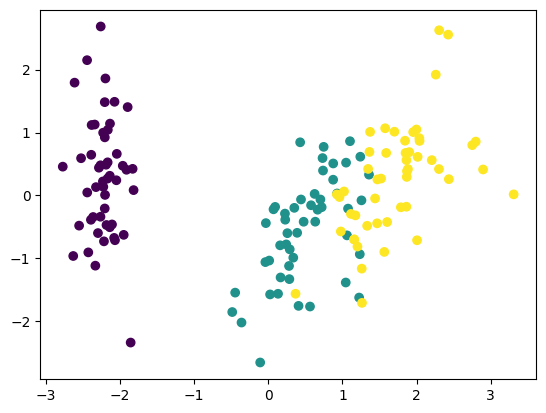

In [31]:
plt.scatter(pca_scaled[:, 0], pca_scaled[:, 1], c= y)
plt.show()

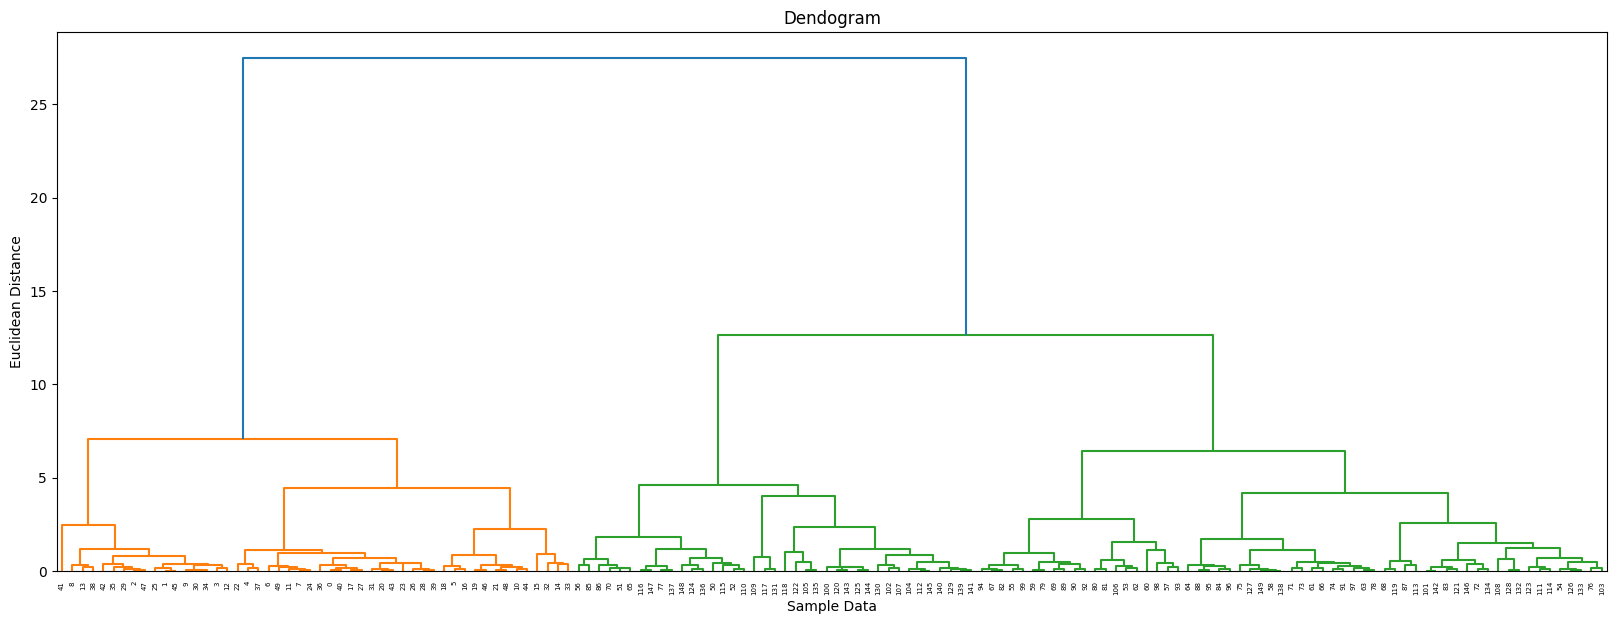

In [32]:
# Agglomerative clustering >> make dendogram

import scipy.cluster.hierarchy as sc

plt.figure(figsize= (20, 7))
plt.title("Dendogram")

sc.dendrogram(sc.linkage(pca_scaled, method= 'ward'))
plt.xlabel("Sample Data")
plt.ylabel("Euclidean Distance")

plt.show()

In [33]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters= 2, metric= 'euclidean', linkage= 'ward')
cluster

AgglomerativeClustering()

In [34]:
cluster.fit(pca_scaled)

AgglomerativeClustering()

In [35]:
cluster.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

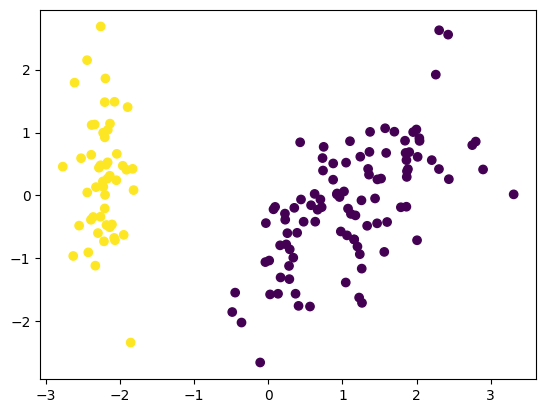

In [36]:
plt.scatter(pca_scaled[:, 0], pca_scaled[:, 1], c= cluster.labels_)
plt.show()

In [37]:
from sklearn.metrics import silhouette_score

silhouette_coef = []
for k in range(2, 11):
  agglo = AgglomerativeClustering(n_clusters= k, metric= 'euclidean', linkage= 'ward')
  agglo.fit(pca_scaled)
  score = silhouette_score(pca_scaled, agglo.labels_)
  silhouette_coef.append(score)


silhouette_coef

[np.float64(0.6145202036230452),
 np.float64(0.5110595988766189),
 np.float64(0.4487350420958893),
 np.float64(0.4041689631006268),
 np.float64(0.36721128895830735),
 np.float64(0.3706820678912666),
 np.float64(0.3930552606912112),
 np.float64(0.4183694466469872),
 np.float64(0.4054205628889491)]